## Import required libraries

In [1]:
%%capture
# 1. نصب virtualenv (اگر لازم باشه)
!pip install virtualenv

# 2. کلون کردن ریپو
!git clone https://github.com/SalesforceAIResearch/uni2ts.git

# 3. رفتن به پوشه پروژه
%cd uni2ts

# 4. نصب از سورس (editable install)
!pip install -e .

In [2]:
%%capture
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from einops import rearrange
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.eval_util.plot import plot_single, plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings('ignore')

Create calculate error metrics function which helps in assessing the performance of the trained model

In [18]:

def calculate_error_metrics(actual, predicted, num_predictors=1):
    # convert inputs are numpy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    # Number of observations
    n = len(actual)
    # Calculate MSE
    mse = mean_squared_error(actual, predicted)
    # Calculate RMSE
    rmse = np.sqrt(mse)
    # Calculate MAPE
    mape = mean_absolute_percentage_error(actual, predicted)
    # Calculate R-squared
    r2 = r2_score(actual, predicted)
    # Calculate Adjusted R-squared
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_predictors - 1))
    print(f'MSE : {mse}')
    print(f'RMSE : {rmse}')
    print(f'MAPE : {mape}')
    print(f'r2 : {r2}')
    print(f'adjusted_r2 : {adjusted_r2}')

Load AirPassengersDataset and dispaly the dataframe

In [25]:
from google.colab import drive
import pandas as pd

# اتصال به گوگل درایو
drive.mount('/content/drive')

# خواندن فایل CSV
df = pd.read_csv('/content/drive/MyDrive/data/Electric_Production.csv')  # نام فایل رو بر اساس فایلت تنظیم کن

# تغییر نام ستون‌ها
df.rename(columns={'DATE': 'ds', 'IPG2211A2N': 'target'}, inplace=True)

# تبدیل ستون تاریخ به datetime
df['ds'] = pd.to_datetime(df['ds'])

# تنظیم ستون تاریخ به عنوان ایندکس
df.set_index('ds', inplace=True)

# چاپ اطلاعات کلی
print(f"Total length: {df.shape[0]}")
print(f"Time frequency: {df.index.to_series().diff().dropna().unique()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total length: 397
Time frequency: <TimedeltaArray>
['31 days', '28 days', '30 days', '29 days']
Length: 4, dtype: timedelta64[ns]


In [26]:
df

,target
ds,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151
...,...
2017-09-01,98.6154
2017-10-01,93.6137
2017-11-01,97.3359


Create a sample for the hourly data

In [34]:
inp = {
    "target": df["target"].to_numpy()[:373],
    "start": df.index[0].to_period(freq="M"),
}
label = {
    "target": df["target"].to_numpy()[373:397],
    "start": df.index[120].to_period(freq="M"),
}

In [35]:
inp

{'target': array([ 72.5052,  70.672 ,  62.4502,  57.4714,  55.3151,  58.0904,
         62.6202,  63.2485,  60.5846,  56.3154,  58.0005,  68.7145,
         73.3057,  67.9869,  62.2221,  57.0329,  55.8137,  59.9005,
         65.7655,  64.4816,  61.0005,  57.5322,  59.3417,  68.1354,
         73.8152,  70.062 ,  65.61  ,  60.1586,  58.8734,  63.8918,
         68.8694,  70.0669,  64.1151,  60.3789,  62.4643,  70.5777,
         79.8703,  76.1622,  70.2928,  63.2384,  61.4065,  67.1097,
         72.9816,  75.7655,  67.5152,  63.2832,  65.1078,  73.8631,
         77.9188,  76.6822,  73.3523,  65.1081,  63.6892,  68.4722,
         74.0301,  75.0448,  69.3053,  65.8735,  69.0706,  84.1949,
         84.3598,  77.1726,  73.1964,  67.2781,  65.8218,  71.4654,
         76.614 ,  77.1052,  73.061 ,  67.4365,  68.5665,  77.6839,
         86.0214,  77.5573,  73.365 ,  67.15  ,  68.8162,  74.8448,
         80.0928,  79.1606,  73.5743,  68.7538,  72.5166,  79.4894,
         85.2855,  80.1643,  74.5275, 

In [36]:
label

{'target': array([106.6688,  95.3548,  89.3254,  90.7369, 104.0375, 114.5397,
        115.5159, 102.7637,  91.4867,  92.89  , 112.7694, 114.8505,
         99.4901, 101.0396,  88.353 ,  92.0805, 102.1532, 112.1538,
        108.9312,  98.6154,  93.6137,  97.3359, 114.7212, 129.4048]),
 'start': Period('1995-01', 'M')}

Let's initialize, train the model and define its hyperparameters

In [38]:
# Prepare model
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),
    prediction_length=24,
    context_length=373,
    patch_size=32,
  num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

# Time series values. Shape: (batch, time, variate)
past_target = rearrange(
    torch.as_tensor(inp["target"], dtype=torch.float32), "t -> 1 t 1"
)
# 1s if the value is observed, 0s otherwise. Shape: (batch, time, variate)
past_observed_target = torch.ones_like(past_target, dtype=torch.bool)
# 1s if the value is padding, 0s otherwise. Shape: (batch, time)
past_is_pad = torch.zeros_like(past_target, dtype=torch.bool).squeeze(-1)

forecast = model(
    past_target=past_target,
    past_observed_target=past_observed_target,
    past_is_pad=past_is_pad,
)

Calculate the error metrics

In [39]:
calculate_error_metrics(label["target"],np.round(np.median(forecast[0], axis=0), decimals=4))

MSE : 162.82894093745531
RMSE : 12.7604443863627
MAPE : 0.09439831744831029
r2 : -0.4949361902937033
adjusted_r2 : -0.5628878353070534


Let's predict

In [40]:
print(
    "median prediction:\n",
    np.round(np.median(forecast[0], axis=0), decimals=4),
)
print("ground truth:\n", label["target"])

median prediction:
 [103.8122 101.6987  98.6502  98.2041 100.3497  97.0779  99.145   98.0667
  98.9807  97.2855  95.4458  95.4551  96.8591  96.8973  98.2301  95.6114
  91.884   97.2543  93.0371  92.4193  92.5949  92.3682  95.3448  94.7249]
ground truth:
 [106.6688  95.3548  89.3254  90.7369 104.0375 114.5397 115.5159 102.7637
  91.4867  92.89   112.7694 114.8505  99.4901 101.0396  88.353   92.0805
 102.1532 112.1538 108.9312  98.6154  93.6137  97.3359 114.7212 129.4048]


Visualize the predictions

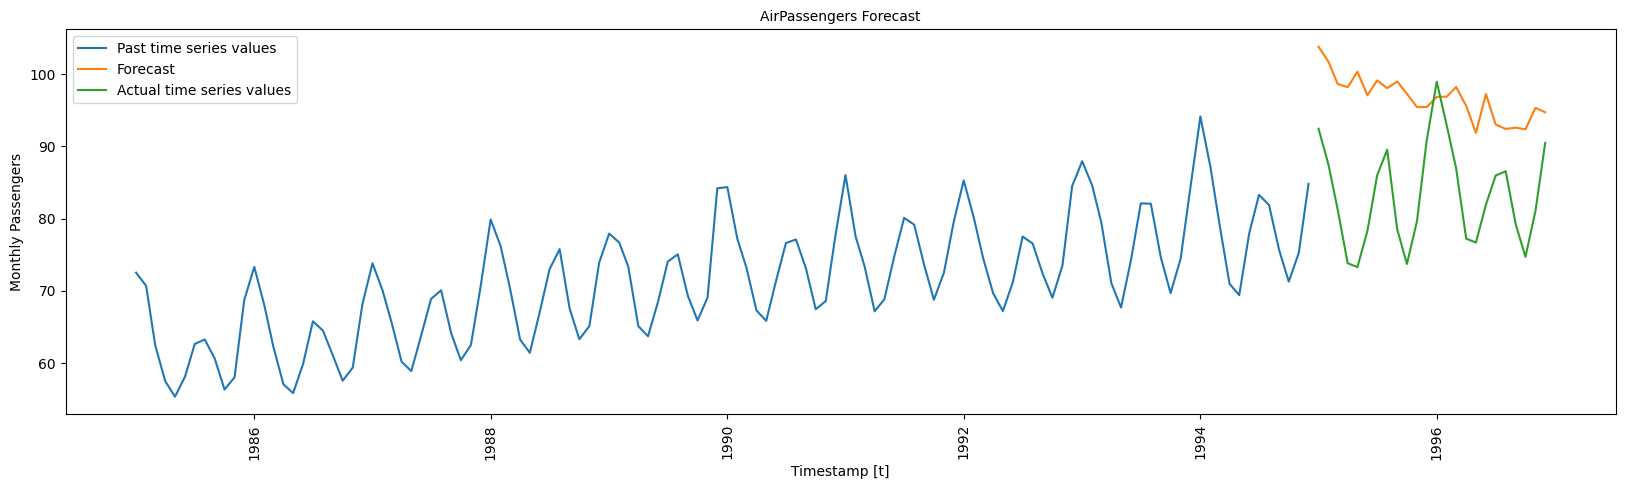

In [41]:
df_test = df["target"][120:144]
df_train = df["target"][:120]
df_test = df_test.reset_index().rename(columns={"index":"ds"})
df_train = df_train.reset_index().rename(columns={"index":"ds"})
df_test['Predicted']= pd.Series(np.round(np.median(forecast[0], axis=0), decimals=4))
df_train.set_index('ds',inplace =True)
df_test.set_index('ds',inplace =True)
plt.figure(figsize=(20, 5))
y_past = df_train["target"]
y_pred = df_test['Predicted']
y_test = df_test["target"]
plt.plot(y_past, label="Past time series values")
plt.plot(y_pred, label="Forecast")
plt.plot(y_test, label="Actual time series values")
plt.title('AirPassengers Forecast', fontsize=10)
plt.ylabel('Monthly Passengers', fontsize=10)
plt.xlabel('Timestamp [t]', fontsize=10)
#plt.tight_layout()
plt.xticks(rotation=90)
plt.legend();